In [1]:
import os
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner
from pesummary.io import read
from pesummary.gw.conversions.mass import mchirp_from_mtotal_q, component_masses_from_mtotal_q
from simple_pe.param_est import SimplePESamples

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from us

lal.MSUN_SI != Msun


In [3]:
def make_comparison(run_dir, bilby_samples, trues=None):

    # Load posterior samples
    params = ['chirp_mass', 'mass_ratio', 'chi_align', 'ecc10']
    samples_path = os.path.join(run_dir, 'outdir', 'output', 'posterior_samples.dat')
    all_samples = SimplePESamples(read(samples_path).samples_dict)
    all_samples.generate_all_posterior_samples()
    all_samples.generate_ecc()
    samples = np.array([np.array(all_samples[param]) for param in params]).T

    # Load true values
    if trues == None:
        inj_path = os.path.join(run_dir, 'outdir', 'output', 'converted_injection_parameters.json')
        with open(inj_path, 'r') as f:
            inj_dict = json.load(f)
        print(inj_dict['posterior_samples'])
        trues = [inj_dict['posterior_samples'][param][0] for param in params]

    # Make corner plot
    labels = ['$\mathcal{M}~/~M_\odot$', '$q$', '$\chi_\mathrm{align}$', '$e_{10}$']
    fig = corner.corner(samples, smooth=1, color='C0', truths=trues, truth_color='C1',
                        plot_datapoints=True, plot_density=False, fill_contours=True,
                        labels=labels, hist_kwargs={'density': True})

    # Load and plot bilby posterior
    with h5py.File(bilby_samples, 'r') as file:
        chirp = np.array(file['posterior']['chirp_mass'])
        q = np.array(file['posterior']['mass_ratio'])
        chi_1 = np.array(file['posterior']['chi_1'])
        chi_2 = np.array(file['posterior']['chi_2'])
        ecc10 = np.array(file['posterior']['eccentricity'])
    chi_align = (chi_1 + q**(4/3)*chi_2)/(1 + q**(4/3))
    bilby_posterior = np.array([chirp, q, chi_align, ecc10]).T
    corner.corner(bilby_posterior, smooth=1, color='C2', fig=fig, hist_kwargs={'density': True},
                  plot_datapoints=True, plot_density=False, fill_contours=True)

    # Make legend
    colors = ['C0', 'C2']
    sample_labels = ['simple-pe', 'bilby']
    plt.legend(
        handles=[
            mlines.Line2D([], [], color=colors[i], label=sample_labels[i])
            for i in range(2)
        ],
        fontsize=20, frameon=False,
        bbox_to_anchor=(0, 4), loc="upper right"
    )

2026-05-26  09:09:58 PESummary WARNING : Failed to find 'log_likelihood' in result file. Setting every sample to have log_likelihood 0
2026-05-26  09:09:58 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-05-26  09:09:58 PESummary WARNING : Could not find delta_f in input file and one was not passed from the command line. Using 0.00390625Hz as default
2026-05-26  09:09:58 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default
2026-05-26  09:09:58 PESummary WARNING : Could not find f_low in input file and one was not passed from the command line. Using 20.0Hz as default
2026-05-26  09:09:58 PESummary INFO    : chi_p = 0 for all samples. Treating this as a non-precessing system
2026-05-26  09:09:58 PESummary WARNING : The redshift is being approximated using interpolation. Bear in mind that this does introduce a small error.
2026-05-

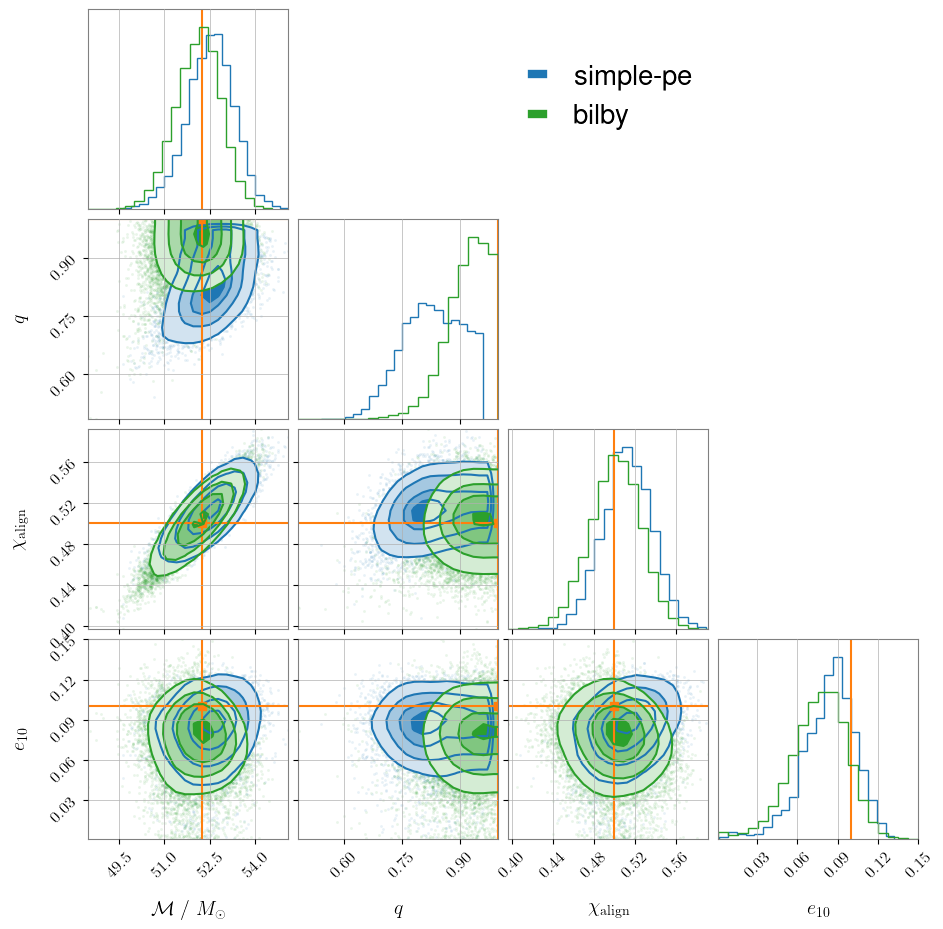

In [5]:
total_m = 120
q = 1
chirp = mchirp_from_mtotal_q(total_m, q)
chi_1 = 0.5
chi_2 = 0.5
chi_align = (chi_1 + q**(4/3)*chi_2)/(1 + q**(4/3))
ecc10 = 0.1
trues = [chirp, q, chi_align, ecc10]
run_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/bilby_comparison/TEOB_chi0_5_ecc0_1/offset_0'
bilby_samples = '/home/ben.patterson/public_html/EPETF/injection_study_bilby_highM/all_runs/M_120_chi_eff_0_5_ecc_0_1_injection_TEOBResumSDALI_recovery_TEOBResumSDALI/samples/samples.hdf5'
make_comparison(run_dir, bilby_samples=bilby_samples, trues=trues)